# Model Evaluation: Kernel Density Estimation (KDE) per Criterion

This notebook generates KDE plots for each evaluation criterion, allowing you to compare the distribution of scores across the top-N models.

In [1]:
try:
    import matplotlib_inline
    matplotlib_inline.backend_inline.set_matplotlib_formats('svg', 'pdf')
except ImportError:
    pass
import sys
import os
current_dir = os.path.abspath('')
if os.path.basename(current_dir) == 'query_eval':
    project_root = os.path.abspath(os.path.join(current_dir, '..'))
    sys.path = [p for p in sys.path if os.path.abspath(p) != current_dir]
    if project_root not in sys.path:
        sys.path.insert(0, project_root)
    os.chdir(project_root)
import query_eval.utils.kde_utils as kde_utils

## Configuration

In [2]:
# Target directory containing the CSV files. 
# Set to 'latest' to automatically pick the most recent execution directory.
TARGET_DIR = 'outputs/query_eval/archive_04-2026_to_06-2026/20260506_174536 E2 (keep)' 

# Number of top models to show based on overall scores
TOP_N = 3

# Smoothing adjustment for KDE plots. 1.0 is default Seaborn. 0.5 is half smoothing for more detailed shapes.
BW_ADJUST = 0.5

In [3]:
# Resolve latest directory if requested
TARGET_DIR = kde_utils.resolve_target_dir(TARGET_DIR)

Using directory: outputs/query_eval/archive_04-2026_to_06-2026/20260506_174536 E2 (keep)


## Load Data

In [4]:
# Load the overall scores and all run data for the top N models
df_runs_top = kde_utils.load_evaluation_data(TARGET_DIR, TOP_N)

Top 3 models based on Weighted_Overall: gemma4:26b, ministral-3:14b, qwen3.6:35b-a3b


In [5]:
# Translate criterion names for the plots
criterios_es = {
    "Syntactic Correctness (Well-formedness)": "Corrección Sintáctica",
    "Semantic Faithfulness": "Fidelidad Semántica",
    "Structural Quality": "Calidad Estructural",
    "Hypothesis Quality": "Gestión de Hipótesis",
    "Minimality and Non-redundancy": "Minimalidad y no Redundancia",
    "Aggregation and Projection Correctness": "Correctitud de Agregaciones y Proyecciones"
}

# Replace in the dataframe
df_runs_top["Criterion"] = df_runs_top["Criterion"].replace(criterios_es)

# Replace the internal order of kde_utils to match in the plots
kde_utils.CRITERION_ORDER = [criterios_es.get(c, c) for c in kde_utils.CRITERION_ORDER]

## KDE Plots per Criterion

## Histogram Plots per Criterion
Shows the absolute count of evaluations grouped by evaluation scores. Very useful for discerning discrete rating distributions (e.g. exactly 0, 0.5, or 1).

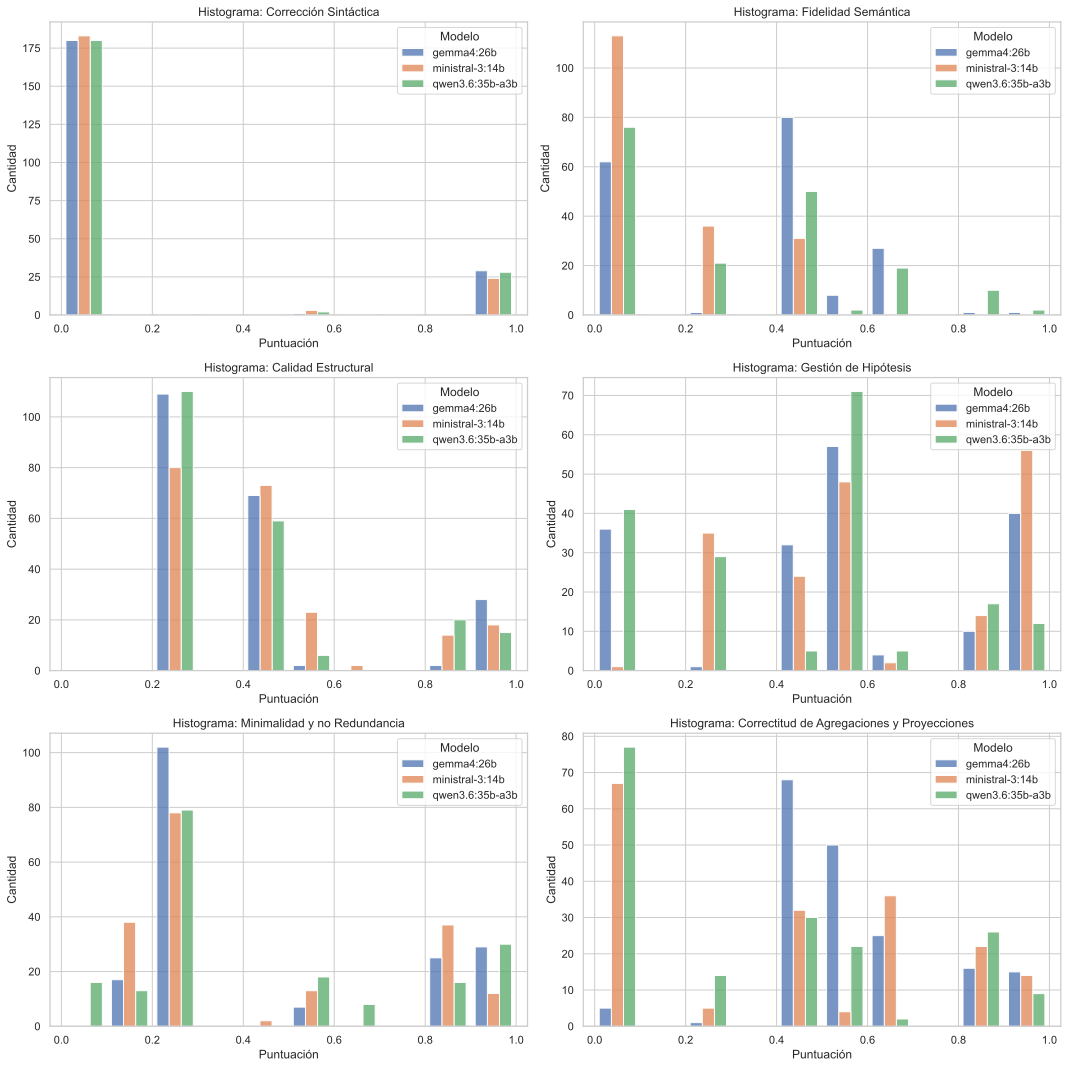

In [6]:
# Generate Histogram plots
kde_utils.plot_histogram_per_criterion(df_runs_top)

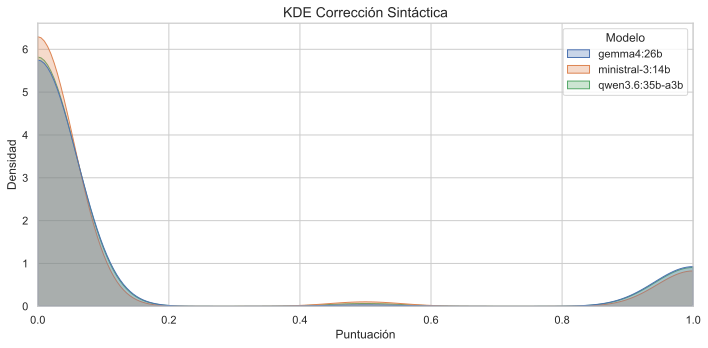

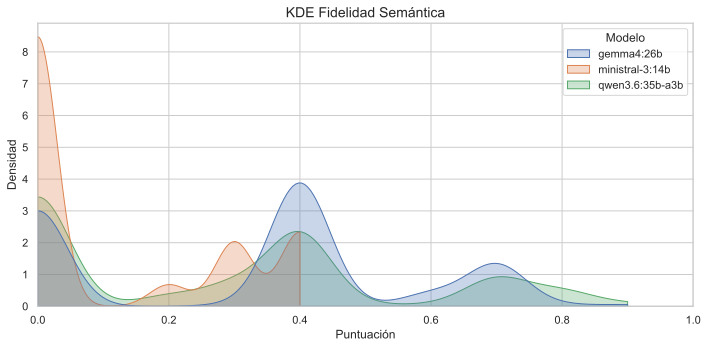

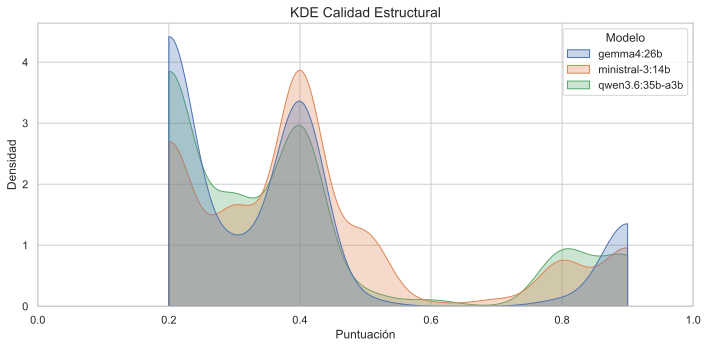

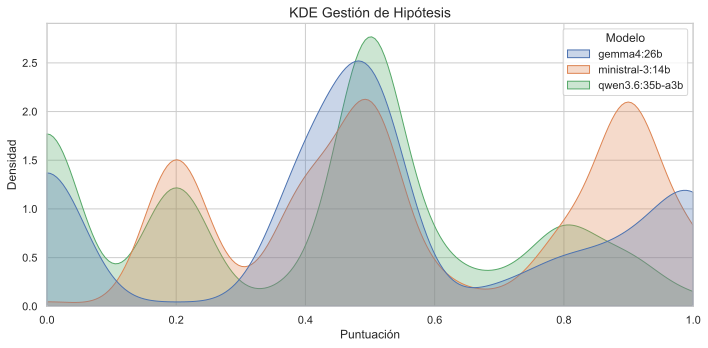

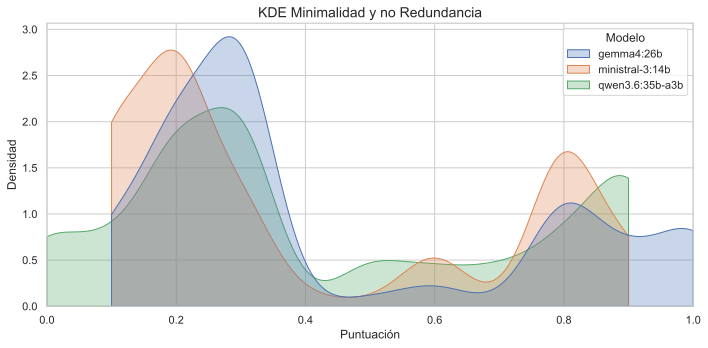

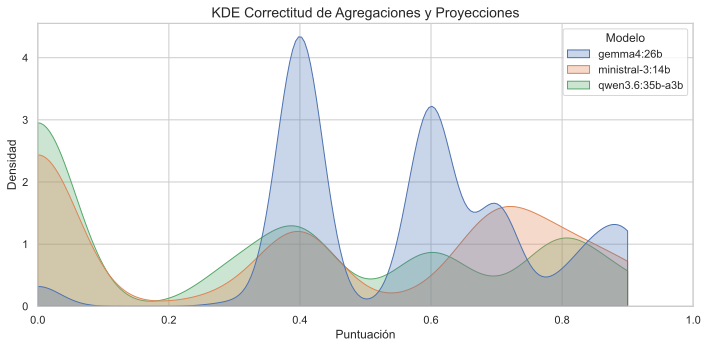

In [7]:
# Generate the KDE plots
kde_utils.plot_kde_per_criterion(df_runs_top, bw_adjust=BW_ADJUST)

## Cumulative KDE Plot
Shows the accumulative distribution. Very useful for determining what percentage of the executions scored equal to or less than a specific value.

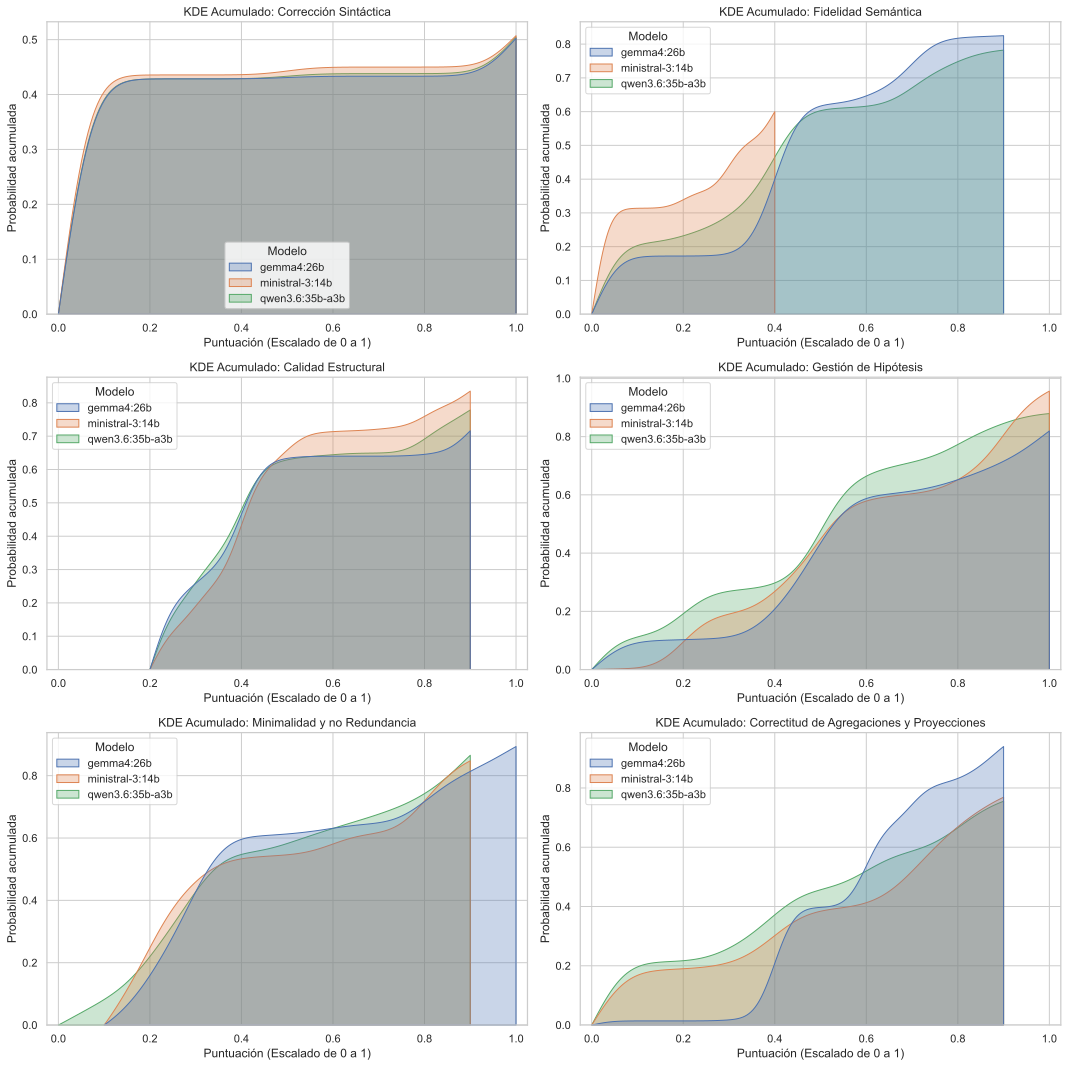

In [8]:
kde_utils.plot_cumulative_kde_per_criterion(df_runs_top, bw_adjust=BW_ADJUST)

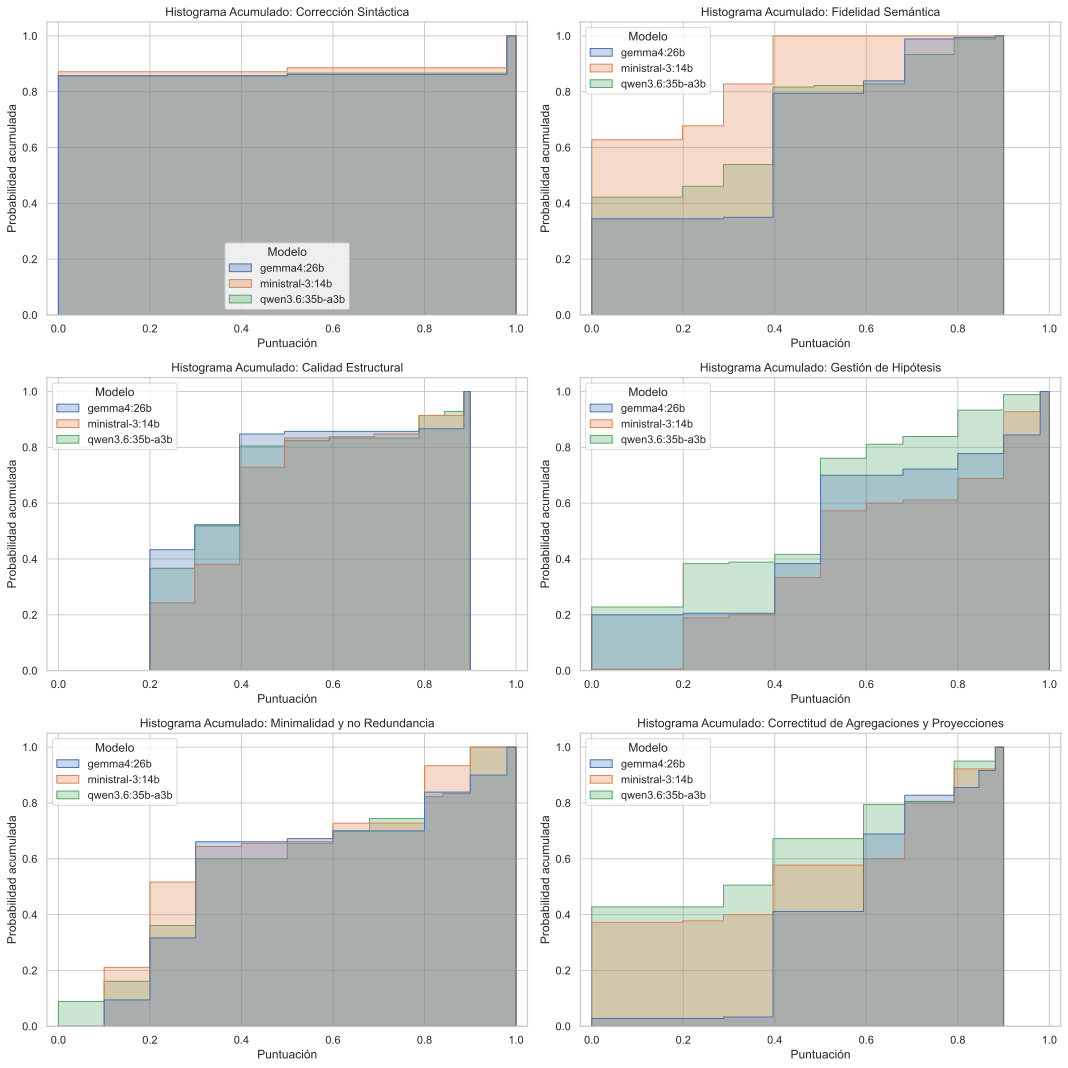

In [9]:
kde_utils.plot_cumulative_histogram_per_criterion(df_runs_top)

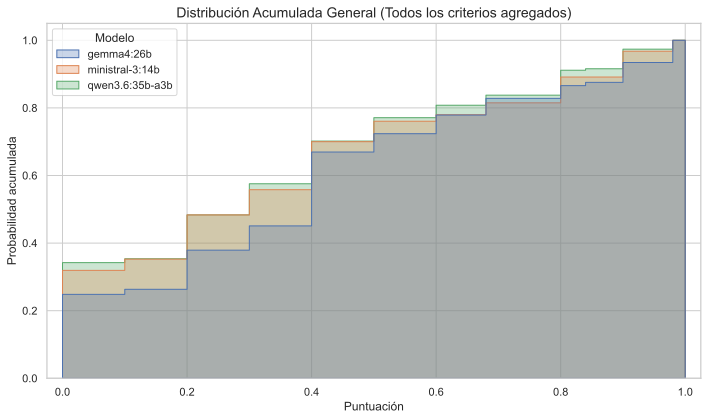

In [10]:
kde_utils.plot_overall_cumulative_histogram(df_runs_top)

## Overall KDE Signature Plot
Combines all criteria to visualize the overall density signature of each model in a single chart.

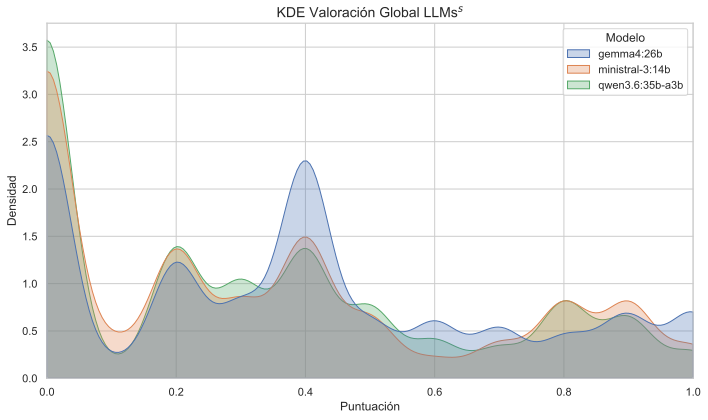

In [11]:
# Generate Overall KDE Plot
kde_utils.plot_overall_kde(df_runs_top, bw_adjust=BW_ADJUST)